In [ ]:
from pathlib import Path

import pandas as pd                 #Manipulação e analise de dados
import matplotlib.pyplot as plt     # Plotagem de gráficos

In [2]:
# ============================================================
# DESCOBRE A PASTA PRINCIPAL DO PROJETO
# ============================================================

if Path.cwd().name == "notebooks":
    BASE = Path.cwd().parent
else:
    BASE = Path.cwd()

CAMINHO_DADOS = BASE / "data" / "processed" / "gaitdb.csv"

print(CAMINHO_DADOS)

c:\Users\danie\OneDrive\Documentos\Mestrado\Engenharia de Dados e IA\gaitdb_project\data\processed\gaitdb.csv


In [4]:
# ============================================================
# CARREGA OS DADOS
# ============================================================

dados = pd.read_csv(CAMINHO_DADOS)

dados.head()

,participante_id,grupo,idade,tempo_(s),intervalo_passada_(s)
0,o1,idoso,76.0,30.797,1.023
1,o1,idoso,76.0,31.820,1.030
2,o1,idoso,76.0,32.850,1.017
3,o1,idoso,76.0,33.867,1.027
4,o1,idoso,76.0,34.893,1.043


In [5]:
# ============================================================
# TAMANHO DO DATASET
# ============================================================

linhas, colunas = dados.shape

print(f"Número de registros: {linhas}")
print(f"Número de variáveis: {colunas}")

Número de registros: 9144
Número de variáveis: 5


In [6]:
# ============================================================
# TIPO DE DADO DE CADA VARIÁVEL
# ============================================================
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 9144 entries, 0 to 9143
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   participante_id        9144 non-null   str    
 1   grupo                  9144 non-null   str    
 2   idade                  7923 non-null   float64
 3   tempo_(s)              9144 non-null   float64
 4   intervalo_passada_(s)  9144 non-null   float64
dtypes: float64(3), str(2)
memory usage: 425.8 KB


In [7]:
# ============================================================
# HÁ VALORES AUSENTES? QUANTOS?
# ============================================================
dados.isna().sum()

participante_id             0
grupo                       0
idade                    1221
tempo_(s)                   0
intervalo_passada_(s)       0
dtype: int64

In [10]:
#QUANTIDADE DE PARTICIPANTES
numero_participantes = dados["participante_id"].nunique()  #Número de valores únicos

print(f"Número de participantes: {numero_participantes}")


#QUANTIDADE DE PARTICIPANTES POR GRUPO

participantes_grupo = (
    dados.groupby("grupo")        # groupby = Separe os dados de acordo com determinada variável.
    ["participante_id"].nunique()
)

participantes_grupo

Número de participantes: 15


grupo
idoso        5
jovem        5
parkinson    5
Name: participante_id, dtype: int64

In [11]:
# ============================================================
# PASSADAS POR PARTICIPANTES
# ============================================================

passadas_participante = (
    dados.groupby(
        ["participante_id", "grupo"]
    )
    .size()
    .reset_index(name="numero_passadas")
)

passadas_participante

,participante_id,grupo,numero_passadas
0,o1,idoso,815
1,o2,idoso,720
2,o3,idoso,892
3,o4,idoso,877
4,o5,idoso,806
5,pd1,parkinson,222
6,pd2,parkinson,263
7,pd3,parkinson,203
8,pd4,parkinson,288
9,pd5,parkinson,245


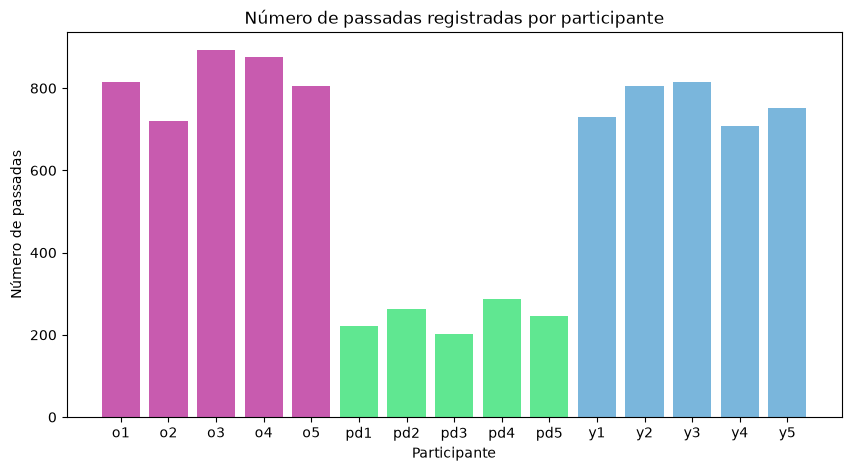

In [15]:
# ============================================================
# GRÁFICO DE PASSADAS POR PARTICIPANTE
# ============================================================

cores = {
    "jovem": "#7AB6DC",
    "idoso": "#C85BAF",
    "parkinson": "#60E791"
}

cores_barras = passadas_participante["grupo"].map(cores)

plt.figure(figsize=(10, 5))

plt.bar(
    passadas_participante["participante_id"],
    passadas_participante["numero_passadas"],
    color=cores_barras
)

plt.xlabel("Participante")
plt.ylabel("Número de passadas")
plt.title("Número de passadas registradas por participante")
plt.Colorizer

plt.show()

In [24]:
#COMPARAÇÃO DOS TRÊS GRUPOS

estatisticas_grupo = (
    dados.groupby("grupo")["intervalo_passada_(s)"]
    .agg( Registro="count",
          Média="mean", 
          Desvio_Padrão="std",
          Mediana= "median",
          Min= "min",
          Max= "max")
)

estatisticas_grupo

,Registro,Média,Desvio_Padrão,Mediana,Min,Max
grupo,,,,,,
idoso,4110,1.021679,0.083542,1.0200,0.830,1.9900
jovem,3813,1.101055,0.064379,1.1030,0.977,1.2700
parkinson,1221,1.138236,0.162533,1.1133,0.520,1.8267


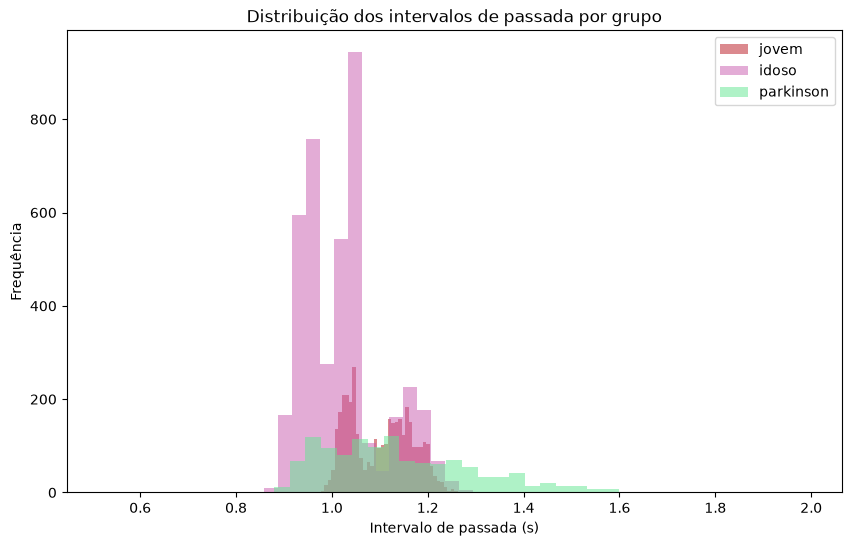

In [28]:
# ============================================================
# DISTRIBUIÇÃO DO INTERVALO DE PASSADA POR GRUPO
# ============================================================

grupos = ["jovem", "idoso", "parkinson"]

cores = {
    "jovem": "#7AB6DC",
    "idoso": "#C85BAF",
    "parkinson": "#60E791"
}

plt.figure(figsize=(10, 6))

for grupo in grupos:

    dados_grupo = dados[
        dados["grupo"] == grupo
    ]

    plt.hist(
        dados_grupo["intervalo_passada_(s)"],
        bins=40,
        alpha=0.5,
        label=grupo,
        color=cores[grupo]
    )

plt.xlabel("Intervalo de passada (s)")
plt.ylabel("Frequência")
plt.title("Distribuição dos intervalos de passada por grupo")

plt.legend()

plt.show()

In [31]:
# ============================================================
# ESTATÍSTICAS POR PARTICIPANTE
# ============================================================

estatisticas_participante = (
    dados.groupby(
        ["participante_id", "grupo"]
    )["intervalo_passada_(s)"]
    .agg(
        Numero_passadas="count",
        Media="mean",
        Desvio_Padrão="std",
        Mediana="median",
        Min="min",
        Max="max"
    )
    .reset_index()
)

estatisticas_participante

,participante_id,grupo,Numero_passadas,Media,Desvio_Padrão,Mediana,Min,Max
0,o1,idoso,815,1.030661,0.017749,1.03300,0.9230,1.0830
1,o2,idoso,720,1.167703,0.050415,1.16700,0.8770,1.9900
2,o3,idoso,892,0.940825,0.030181,0.93700,0.8830,1.0800
3,o4,idoso,877,0.956881,0.018388,0.95700,0.8300,1.0270
4,o5,idoso,806,1.042140,0.016408,1.04300,0.8970,1.1170
5,pd1,parkinson,222,1.250556,0.079825,1.25165,0.7767,1.5400
6,pd2,parkinson,263,1.057805,0.050411,1.05330,0.8433,1.4400
7,pd3,parkinson,203,1.369439,0.140458,1.37330,0.7333,1.8267
8,pd4,parkinson,288,0.965625,0.079297,0.96500,0.5200,1.6900
9,pd5,parkinson,245,1.134138,0.041802,1.13330,1.0133,1.3033


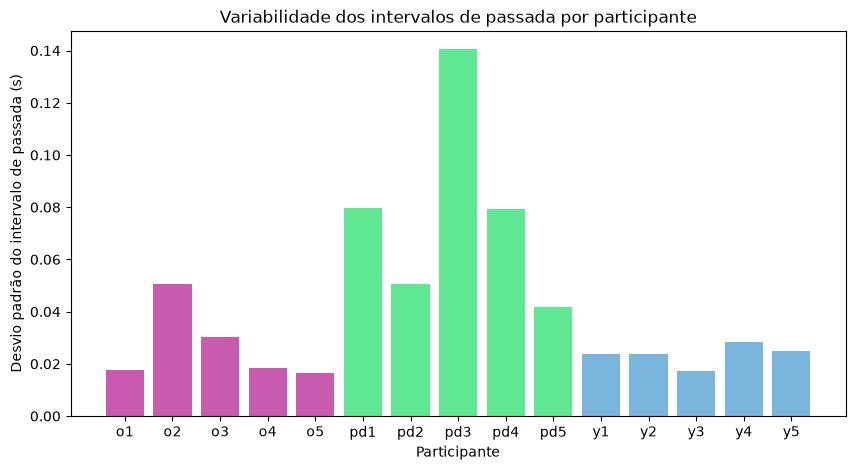

In [33]:
# ============================================================
# VARIABILIDADE DA MARCHA POR PARTICIPANTE
# ============================================================

cores_participantes = estatisticas_participante["grupo"].map(
    {
        "jovem": "#7AB6DC",
        "idoso": "#C85BAF",
        "parkinson": "#60E791"
    }
)

plt.figure(figsize=(10, 5))

plt.bar(
    estatisticas_participante["participante_id"],
    estatisticas_participante["Desvio_Padrão"],
    color=cores_participantes
)

plt.xlabel("Participante")
plt.ylabel("Desvio padrão do intervalo de passada (s)")
plt.title("Variabilidade dos intervalos de passada por participante")

plt.show()